In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
    f1_score
)

import xgboost as xgb

In [3]:
# Cell 2: Load dataset

data = pd.read_csv("..\data\processed\cleaned.csv")

print(data.shape)
data.head()

(7043, 46)


<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Niku\AppData\Local\Temp\ipykernel_42888\1448316169.py:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  data = pd.read_csv("..\data\processed\cleaned.csv")


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,1,29.85,29.85,True,False,False,True,True,False,...,True,False,False,False,True,False,False,True,False,0
1,0,34,56.95,1889.50,False,True,True,False,True,False,...,False,True,False,True,False,False,False,False,True,0
2,0,2,53.85,108.15,False,True,True,False,True,False,...,True,False,False,False,True,False,False,False,True,1
3,0,45,42.30,1840.75,False,True,True,False,True,False,...,False,True,False,True,False,True,False,False,False,0
4,0,2,70.70,151.65,True,False,True,False,True,False,...,True,False,False,False,True,False,False,True,False,1


In [4]:
X = data.drop(columns=["Churn"])
y = data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [22]:

def add_features(df):
    df = df.copy()

    # --- Core features ---
    df["AvgMonthlySpend"] = df["TotalCharges"] / (df["tenure"] + 1)
    df["ChargePerTenure"] = df["MonthlyCharges"] / (df["tenure"] + 1)
    df["CLV_proxy"] = df["tenure"] * df["MonthlyCharges"]

    # --- Risk flags ---
    df["IsMonthToMonth"] = df["Contract_Month-to-month"]
    df["IsFiber"] = df["InternetService_Fiber optic"]
    df["IsElectronicPayment"] = df["PaymentMethod_Electronic check"]

    # --- Interactions ---
    df["MM_Paperless"] = df["Contract_Month-to-month"] * df["PaperlessBilling_Yes"]
    df["Fiber_HighCharge"] = df["InternetService_Fiber optic"] * (
        df["MonthlyCharges"] > df["MonthlyCharges"].median()
    )
    df["Tenure_Charge"] = df["tenure"] * df["MonthlyCharges"]

    # --- Nonlinear transforms ---
    df["log_tenure"] = np.log1p(df["tenure"])
    df["log_totalcharges"] = np.log1p(df["TotalCharges"])

    # --- Binning ---
    df["TenureGroup"] = pd.cut(df["tenure"], bins=[0,12,24,48,72], labels=[0,1,2,3])
    df["ChargeGroup"] = pd.qcut(df["MonthlyCharges"], q=4, labels=False, duplicates="drop")
    df["Fiber_MonthToMonth"] = (
    df["InternetService_Fiber optic"] * df["Contract_Month-to-month"]
)

    df["NoSecurity"] = (df["OnlineSecurity_No"] == 1).astype(int)
    df["NoTechSupport"] = (df["TechSupport_No"] == 1).astype(int)

    df["HighCharge"] = (df["MonthlyCharges"] > 70).astype(int)
    df["LowTenure"] = (df["tenure"] < 6).astype(int)

    df["LowTenure"] = (df["tenure"] < 6).astype(int)
    df["HighCharge"] = (df["MonthlyCharges"] > 70).astype(int)
    df["NoSupport"] = (df["TechSupport_No"] == 1).astype(int)
    df["NoSecurity"] = (df["OnlineSecurity_No"] == 1).astype(int)

    df["Fiber_Month"] = df["InternetService_Fiber optic"] * df["Contract_Month-to-month"]
    return df

X_train = add_features(X_train)
X_test = add_features(X_test)

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [31]:
selected_features = ['Contract_Month-to-month', 'Fiber_MonthToMonth', 'IsFiber', 'NoSecurity', 'ChargePerTenure', 'MM_Paperless', 'OnlineSecurity_No', 'Fiber_HighCharge']
best_xgb_params = {
    "n_estimators": 452,
    "max_depth": 6,
    "learning_rate": 0.016970848716276167,
    "subsample": 0.832177682045614,
    "colsample_bytree": 0.7611462726762261,
    "gamma": 2.822211341448564,
    "reg_alpha": 2.6640667469344,
    "reg_lambda": 2.8568628747407327,
    "scale_pos_weight": 1.0907778176270841,
    "eval_metric": "logloss",
    "tree_method": "hist",
    "random_state": 42
}


In [32]:
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

model = xgb.XGBClassifier(
**best_xgb_params
)

In [33]:
model.fit(X_train[selected_features], y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7611462726762261
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegres

In [34]:
probs = model.predict_proba(X_test[selected_features])[:,1]

In [35]:
thresholds = np.linspace(0.1, 0.5, 100)

best_f1 = 0

for t in thresholds:
    preds = (probs > t).astype(int)
    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

Best threshold: 0.3222222222222222
Best F1: 0.6270996640537514


In [36]:
final_preds = (probs > best_t).astype(int)

print("Accuracy:", accuracy_score(y_test, final_preds))
print("ROC AUC:", roc_auc_score(y_test, probs))
print("F1:", f1_score(y_test, final_preds))

print("\nClassification Report:")
print(classification_report(y_test, final_preds))

Accuracy: 0.7636621717530163
ROC AUC: 0.8357139166602082
F1: 0.6270996640537514

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1035
           1       0.54      0.75      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



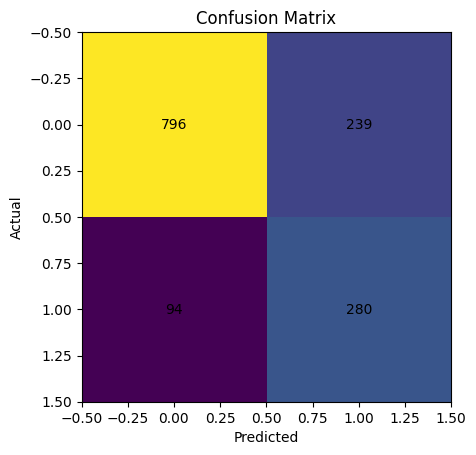

In [37]:
cm = confusion_matrix(y_test, final_preds)

plt.imshow(cm)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

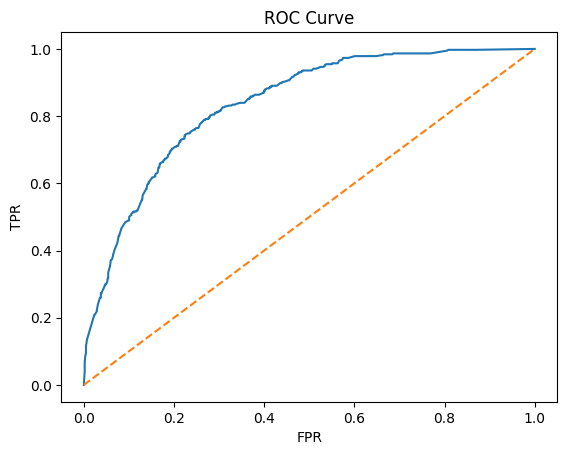

In [38]:
fpr, tpr, _ = roc_curve(y_test, probs)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

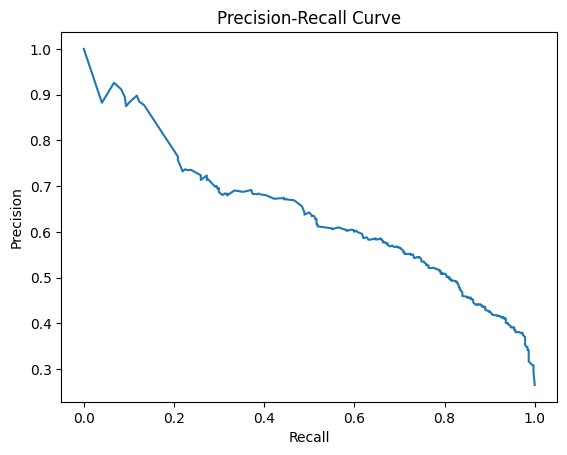

In [39]:
precision, recall, _ = precision_recall_curve(y_test, probs)

plt.plot(recall, precision)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

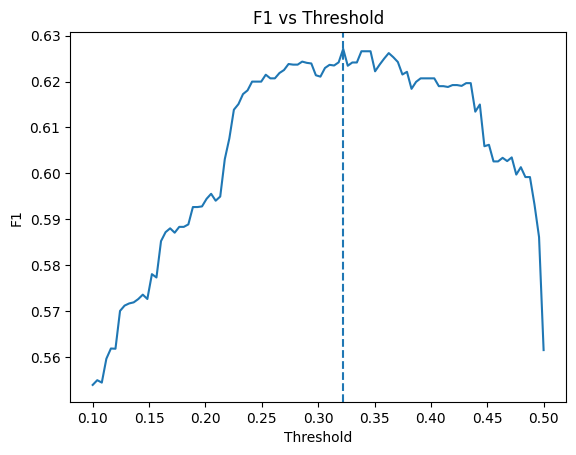

In [40]:
f1s = []

for t in thresholds:
    preds = (probs > t).astype(int)
    f1s.append(f1_score(y_test, preds))

plt.plot(thresholds, f1s)
plt.axvline(best_t, linestyle="--")

plt.title("F1 vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.show()

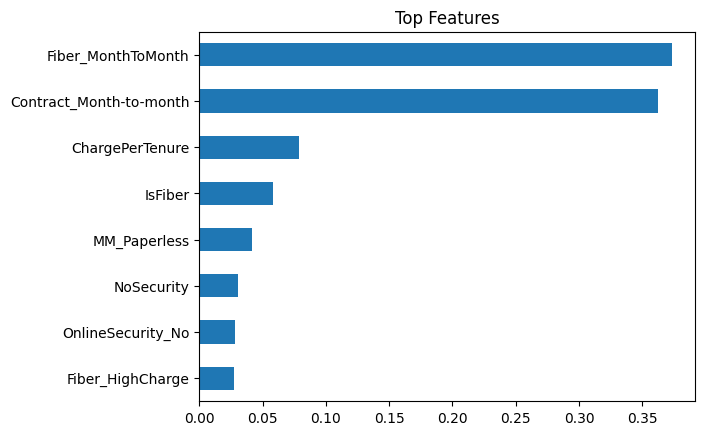

In [41]:
feat_imp = pd.Series(
    model.feature_importances_,
    index=selected_features
).sort_values(ascending=False)

feat_imp.head(20).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top Features")
plt.show()